In [47]:
import torch
import matplotlib.pyplot as plt

n_disc = 100
t = torch.linspace(0, 10, n_disc)

c_0 = torch.zeros_like(t)
c_0[t > 2.5] = 1

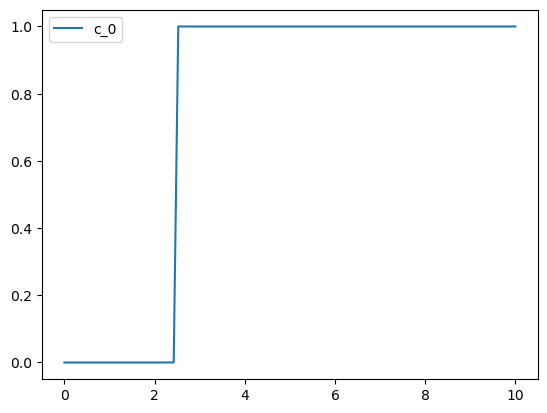

In [48]:
plt.plot(t, c_0, label="c_0")
plt.legend()
plt.show()

Now we need the convolution. We start simple by just performing any convolution:

In [49]:
n_kernel = n_disc
t_kernel = torch.linspace(0, 10, n_kernel)
conv = torch.nn.Conv1d(1, 1, n_kernel, padding_mode="replicate", bias=False)

E_guess = conv.get_parameter("weight")

c = conv(c_0[None, :])

t_c = torch.linspace(2 * t[0], 2 * t[-1], n_disc + n_kernel - 1)

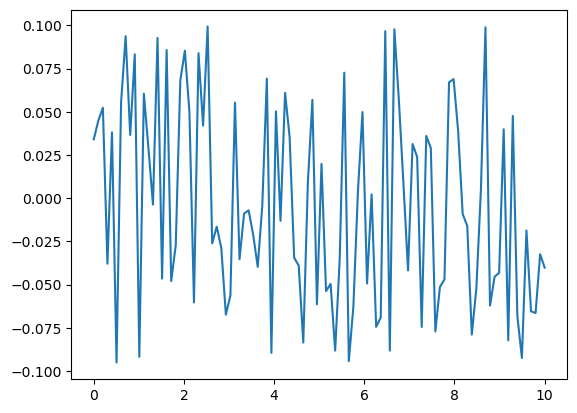

In [50]:
plt.plot(t_kernel, E_guess[0, 0, :].detach().numpy(), label="E_guess")

In [ ]:
plt.plot(c_0, label="c_0")
plt.plot(c[0, :].detach().numpy(), label="c")
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes torch.Size([199]) and (1,)

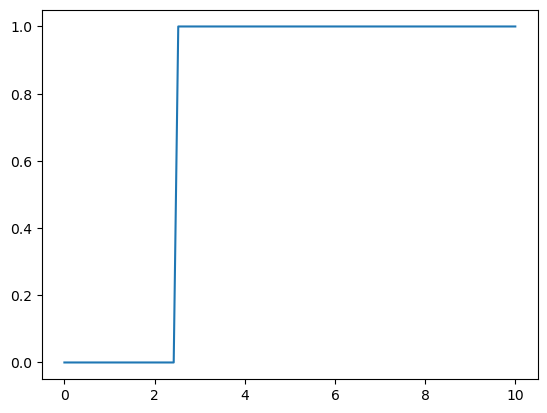

In [51]:
plt.plot(t, c_0, label="c_0")
plt.plot(t_c, c[0, :].detach().numpy(), label="c")
plt.legend()
plt.show()

okay, not bad, it has done something

Now lets investigate. We supply a RTD we know and can derive, what the corresponding c(t) would look like.

Therefore we first need to figure out the actual shape of the convolved kernel.

In [ ]:
list(conv.parameters())[0].shape

torch.Size([1, 1, 40])

In [ ]:
list(conv.parameters())

[Parameter containing:
 tensor([[[ 0.0692, -0.0629,  0.1395,  0.0061,  0.0735,  0.0193,  0.0657,
           -0.0545, -0.0323, -0.0541,  0.0779, -0.1259,  0.0513, -0.0814,
           -0.0132, -0.1561, -0.1471, -0.1436, -0.0028,  0.0800,  0.0250,
           -0.1223, -0.1270, -0.0670,  0.1530, -0.1470, -0.1467,  0.0261,
           -0.1049,  0.0912, -0.0012, -0.0041,  0.0971,  0.0539, -0.1127,
            0.0859, -0.0524, -0.1494, -0.1537,  0.1554]]], requires_grad=True)]

This is the kernel. lets build our own kernel:

In [ ]:
E_own = torch.zeros((1, 1, 40))

E_own[:, :, 20] = 1